In [1]:
!pip install "numpy<2"

In [2]:
!pip install scikit-surprise

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle
import warnings
warnings.filterwarnings('ignore')

In [4]:
from surprise import Dataset, Reader, SVD
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.model_selection import train_test_split, cross_validate
from surprise.accuracy import mse, mae, rmse
from surprise import accuracy

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split as sklearn_train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(29)
torch.manual_seed(29)

In [8]:
rating_df = pd.read_csv('/kaggle/input/datasets/omarabdelhamedomar/movie-lens/ratings.csv')
movies_data = pd.read_csv('/kaggle/input/datasets/omarabdelhamedomar/movie-lens/movies.csv')

In [9]:
rating_df['timestamp'] = rating_df['timestamp'].astype('int64')

In [10]:
min_user_ratings = 20
min_movie_ratings = 20

user_counts = rating_df['userId'].value_counts()
movie_counts = rating_df['movieId'].value_counts()

In [11]:
valid_users = user_counts[user_counts >= min_user_ratings].index
valid_movies = movie_counts[movie_counts >= min_movie_ratings].index

filtered_ratings = rating_df[
    (rating_df['userId'].isin(valid_users)) & 
    (rating_df['movieId'].isin(valid_movies))
]


In [12]:
rating_df_clean = filtered_ratings.copy()

In [13]:
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

rating_df_clean['user_encoded'] = user_encoder.fit_transform(rating_df_clean['userId'])
rating_df_clean['movie_encoded'] = movie_encoder.fit_transform(rating_df_clean['movieId'])

n_users = rating_df_clean['user_encoded'].nunique()
n_movies = rating_df_clean['movie_encoded'].nunique()

In [14]:
train_data, test_data = sklearn_train_test_split(rating_df_clean, test_size=0.2, random_state=42)

In [15]:
print(f"\nTrain set size: {len(train_data)}")
print(f"Test set size: {len(test_data)}")


Train set size: 54318
Test set size: 13580


In [16]:
reader = Reader(rating_scale=(0.5, 5.0))
surprise_data = Dataset.load_from_df(rating_df_clean[['userId', 'movieId', 'rating']], reader)

In [17]:
def create_dataset(data):
    users = torch.LongTensor(data['user_encoded'].values)
    movies = torch.LongTensor(data['movie_encoded'].values)
    ratings = torch.FloatTensor(data['rating'].values)
    return TensorDataset(users, movies, ratings)

In [18]:
train_dataset = create_dataset(train_data)
test_dataset = create_dataset(test_data)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

In [20]:
class NCF(nn.Module):
    def __init__(self, n_users, n_movies, n_factors=50, hidden_units=[128, 64], dropout=0.2):
        super(NCF, self).__init__()
        
        self.user_embedding = nn.Embedding(n_users, n_factors)
        self.movie_embedding = nn.Embedding(n_movies, n_factors)
        self.fc_layers = nn.ModuleList()
        input_size = n_factors * 2
        
        for hidden_size in hidden_units:
            self.fc_layers.append(nn.Linear(input_size, hidden_size))
            self.fc_layers.append(nn.ReLU())
            self.fc_layers.append(nn.Dropout(dropout))
            input_size = hidden_size
        
        self.output_layer = nn.Linear(input_size, 1)
        self._init_weights()
    
    def _init_weights(self):
        for layer in self.modules():
            if isinstance(layer, nn.Embedding):
                nn.init.normal_(layer.weight, std=0.01)
            elif isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0)
    
    def forward(self, user_ids, movie_ids):
        user_emb = self.user_embedding(user_ids)
        movie_emb = self.movie_embedding(movie_ids)
        
        x = torch.cat([user_emb, movie_emb], dim=1)
        for layer in self.fc_layers:
            x = layer(x)
    
        rating = self.output_layer(x)
        return rating.squeeze()

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ncf_model = NCF(n_users, n_movies, n_factors=64, hidden_units=[128, 64, 32]).to(device)

In [22]:
criterion = nn.MSELoss()
optimizer = optim.Adam(ncf_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.8)

In [25]:
n_epochs = 40
train_losses = []
test_losses = []

In [26]:
for epoch in range(n_epochs):

    ncf_model.train()
    train_loss = 0
    for batch_users, batch_movies, batch_ratings in train_loader:
        batch_users = batch_users.to(device)
        batch_movies = batch_movies.to(device)
        batch_ratings = batch_ratings.to(device)
        
        optimizer.zero_grad()
        predictions = ncf_model(batch_users, batch_movies)
        loss = criterion(predictions, batch_ratings)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    ncf_model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_users, batch_movies, batch_ratings in test_loader:
            batch_users = batch_users.to(device)
            batch_movies = batch_movies.to(device)
            batch_ratings = batch_ratings.to(device)
            
            predictions = ncf_model(batch_users, batch_movies)
            loss = criterion(predictions, batch_ratings)
            test_loss += loss.item()
    
    scheduler.step()
    
    train_loss /= len(train_loader)
    test_loss /= len(test_loader)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')

Epoch 5/40, Train Loss: 0.8011, Test Loss: 0.6957
Epoch 10/40, Train Loss: 0.7424, Test Loss: 0.7048
Epoch 15/40, Train Loss: 0.6864, Test Loss: 0.7181
Epoch 20/40, Train Loss: 0.6420, Test Loss: 0.7323
Epoch 25/40, Train Loss: 0.5957, Test Loss: 0.7520
Epoch 30/40, Train Loss: 0.5641, Test Loss: 0.7668
Epoch 35/40, Train Loss: 0.5403, Test Loss: 0.7769
Epoch 40/40, Train Loss: 0.5116, Test Loss: 0.7849


In [27]:
ncf_model.eval()
all_predictions = []
all_targets = []


In [28]:
with torch.no_grad():
    for batch_users, batch_movies, batch_ratings in test_loader:
        batch_users = batch_users.to(device)
        batch_movies = batch_movies.to(device)
        batch_ratings = batch_ratings.to(device)
        
        predictions = ncf_model(batch_users, batch_movies)
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_ratings.cpu().numpy())

In [29]:
ncf_rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
ncf_mae = mean_absolute_error(all_targets, all_predictions)

print(f"\nNCF RMSE: {ncf_rmse:.4f}")
print(f"NCF MAE: {ncf_mae:.4f}")


NCF RMSE: 0.8880
NCF MAE: 0.6773


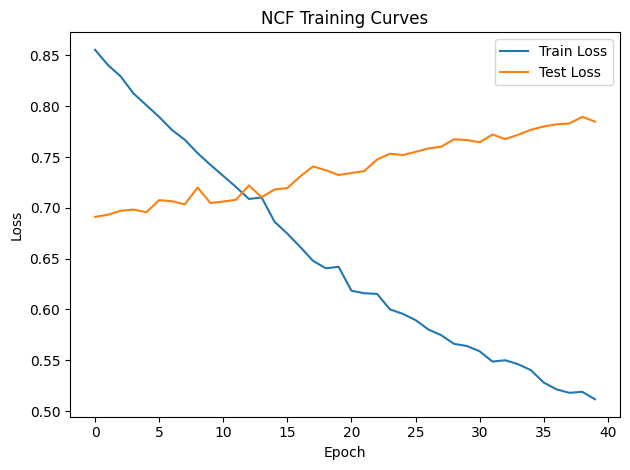

In [30]:
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('NCF Training Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
with open('ncf_model.pkl', 'wb') as f:
    pickle.dump(ncf_model, f)
print("NCF model saved as 'ncf_model.pkl'")

NCF model saved as 'ncf_model.pkl'
